In [5]:
##  1. Loading and Initial Inspection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Initial inspections
print(df.head())
print(df.info())
print(df.describe())
print(df['Churn'].value_counts(normalize=True))  # Overall churn rate

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [9]:
# Create derived features - Improved version
# Fix for TenureGroup to handle tenure=0
df['TenureGroup'] = pd.cut(df['tenure'],
                           bins=[-1, 12, 24, 48, 72, np.inf],
                           labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr', '6+yr'])

# Calculate Average Monthly Charge safely
df['AvgMonthlyCharge'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

# Check missing values again
print("Missing values after feature engineering:")
print(df.isnull().sum())

# Save cleaned version
df.to_csv('cleaned_telco_churn.csv', index=False)
print("Cleaned dataset saved successfully.")

Missing values after feature engineering:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
TenureGroup         0
AvgMonthlyCharge    0
dtype: int64
Cleaned dataset saved successfully.


Overall Churn Rate:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

Churn Rate by Contract:
Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887305  0.112695
Two year        0.971681  0.028319


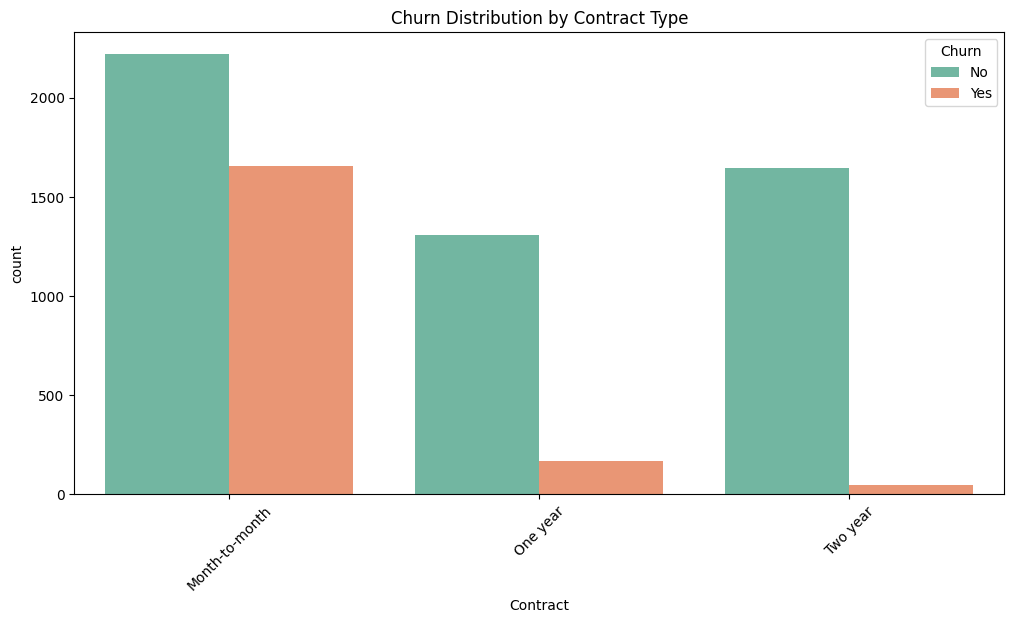

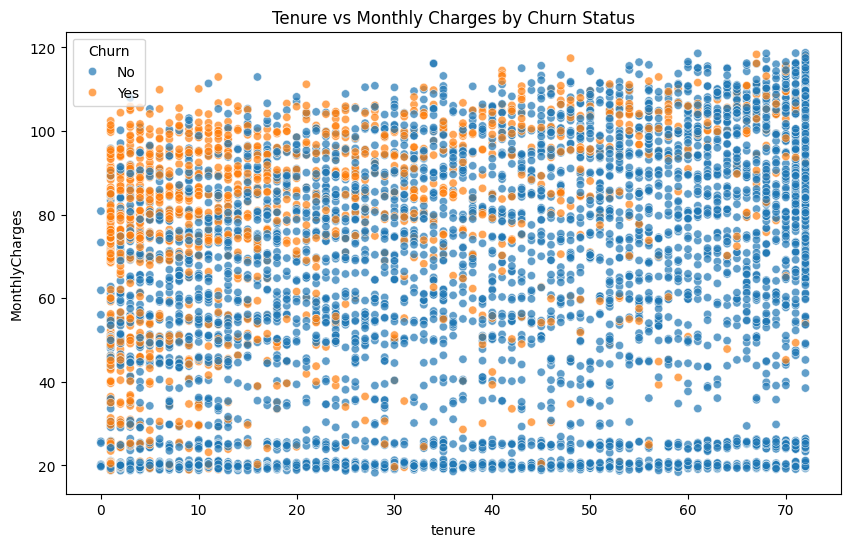

In [10]:
# Overall Churn Rate
churn_rate = df['Churn'].value_counts(normalize=True)
print("Overall Churn Rate:")
print(churn_rate)

# Churn by Contract Type
print("\nChurn Rate by Contract:")
print(df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack())

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Churn Distribution by Contract Type')
plt.xticks(rotation=45)
plt.show()

# Tenure vs Monthly Charges
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', alpha=0.7)
plt.title('Tenure vs Monthly Charges by Churn Status')
plt.show()

Churn by Internet Service and Tech Support:
Churn                                      No       Yes
InternetService TechSupport                            
DSL             No                   0.722446  0.277554
                Yes                  0.903226  0.096774
Fiber optic     No                   0.506278  0.493722
                Yes                  0.773672  0.226328
No              No internet service  0.925950  0.074050

Churn by Demographics:
Churn                        No       Yes
SeniorCitizen Partner                    
0             No       0.699870  0.300130
              Yes      0.833510  0.166490
1             No       0.511424  0.488576
              Yes      0.654450  0.345550

Average Monthly Charges:
Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


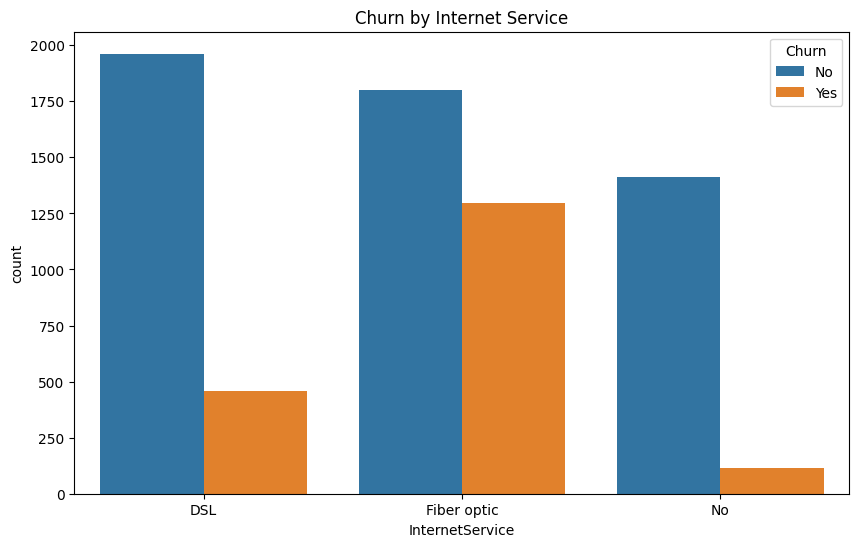

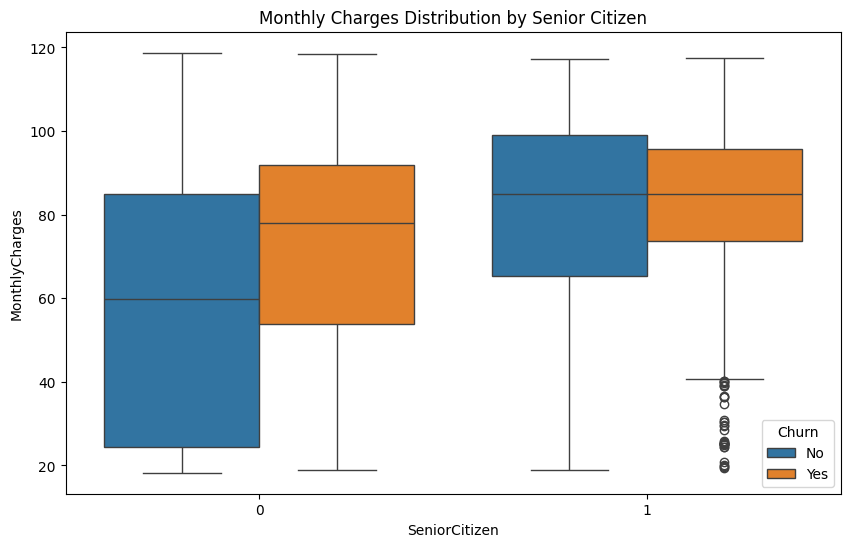

In [11]:
# Additional Insights

# 1. Churn by Internet Service & Tech Support
print("Churn by Internet Service and Tech Support:")
print(df.groupby(['InternetService', 'TechSupport'])['Churn'].value_counts(normalize=True).unstack())

# 2. Churn by Senior Citizen and Partner
print("\nChurn by Demographics:")
print(df.groupby(['SeniorCitizen', 'Partner'])['Churn'].value_counts(normalize=True).unstack())

# 3. Average Monthly Charges by Churn
print("\nAverage Monthly Charges:")
print(df.groupby('Churn')['MonthlyCharges'].mean())

# Visualizations - Add these
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Churn by Internet Service')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='SeniorCitizen', y='MonthlyCharges', hue='Churn')
plt.title('Monthly Charges Distribution by Senior Citizen')
plt.show()

Key Insights:

Customers with Month-to-Month contracts have significantly higher churn (~43%) compared to 1-year and 2-year contracts.
Fiber optic internet users and those without Tech Support show higher churn.
Senior citizens and customers with higher monthly charges are more likely to churn.
Overall churn rate: 26.54%

Business Recommendations:

Offer discounts for longer contracts.
Provide free Tech Support/Online Security bundles for high-risk customers.
Target proactive retention for customers with tenure < 12 months.